# Laptop Price Prediction Using Supervised Machine Learning  
===========================================================================================================================

### Project Overview:
This project aims to develop a regression-based machine learning model to predict laptop prices in euros based on detailed product specifications. Accurate price estimation models have numerous applications in e-commerce pricing engines, recommender systems, and inventory valuation.

---

### Goal:
Predict the laptop selling price (`Price_euros`) using various device features. The model performance is evaluated using **Mean Squared Error (MSE)** and **R-squared (R²)** metrics.

---

### Dataset Description:
The dataset includes specifications for 1275 laptops. It was cleaned to remove 28 duplicate rows, and parsed into separate structured columns for better processing. It comprises 23 columns, with no missing values.

### Key Features Include:
- **Hardware Specs**: `CPU_freq`, `Ram`, `PrimaryStorage`, `SecondaryStorage`, `GPU_model`
- **Display Properties**: `Inches`, `Screen`, `ScreenW`, `ScreenH`, `Touchscreen`, `RetinaDisplay`, `IPSpanel`
- **Build Details**: `Company`, `TypeName`, `Weight`, `Product`
- **Storage Types**: `PrimaryStorageType`, `SecondaryStorageType`
- **Operating System**: `OS`

---

### Methodological Approach:

*1. Data Loading and Inspection*
- Load CSV using pandas.
- Explore structure using `.info()`, `.describe()`, and check for missing/null values.

*2. Exploratory Data Analysis (EDA)*
- Univariate Analysis: Distributions of categorical and continuous features.
- Bivariate Analysis: Relationship of features like `Touchscreen`, `OS`, `RetinaDisplay` with price.
- Visualizations: Bar plots, box plots, scatter plots, and pie charts.

*3. Data Preprocessing*
- Convert categorical variables using One-Hot Encoding.
- Normalize/standardize continuous variables where needed (e.g., `CPU_freq`, `Weight`).
- Remove unnecessary or highly correlated features if multicollinearity is present.

*4. Model Development*
- Baseline model: Linear Regression
- Train-test split (80-20) using `random_state=42`.
- Advanced Models: Ridge and Lasso regressions with hyperparameter tuning using GridSearchCV.

*5. Model Evaluation*
- Evaluate on test set using MSE and R².
- Analyze actual vs. predicted plots.
- Determine variance explained and residual patterns.
- Interpret coefficients for feature importance.

*6. Future Enhancements*
- Try ensemble models (Random Forest, XGBoost).
- Explore dimensionality reduction (PCA).
- Perform cross-validation (K-Fold CV).
- Scrape live e-commerce data for model deployment.

---

### Key Challenges and Solutions:

*1. Data Formatting:*
- Original dataset embedded multiple values in single columns.
- Parsed into granular features for better ML performance.

*2. Categorical Encoding:*
- One-Hot Encoding used for non-ordinal data (e.g., `OS`, `Company`).
- `drop_first=True` used to prevent dummy variable trap.

*3. Feature Correlation:*
- Feature selection based on correlation with target and domain understanding.
- Redundant features eliminated to reduce model complexity.

*4. Model Accuracy:*
- Ridge/Lasso regularization mitigated overfitting.
- Hyperparameter tuning enhanced model generalization.

---

### Project Summary:

- **Problem**: Predict laptop price based on specifications.
- **Solution**: Built regression models (Linear, Ridge, Lasso) using structured EDA and feature engineering.
- **Result**: Achieved explainable predictions with decent accuracy. Ready for integration in e-retail pricing systems.

---

**Author**: Nihal Thakare  
**Date**: 15/04/2024  
**Institution**: Unified Mentor


## Reading data and basic stats

In [38]:
# Import necessary libraries and the dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, chi2
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


Data loaded successfully!

Dataset Overview
• Training Data: 1275 rows, 23 columns

Missing Values Analysis
• No missing values in the dataset.

Feature Types
• Categorical Features: 14
• Numerical Features: 9

Target Variable Summary
count    1275.000000
mean     1134.969059
std       700.752504
min       174.000000
25%       609.000000
50%       989.000000
75%      1496.500000
max      6099.000000
Name: Price_euros, dtype: float64


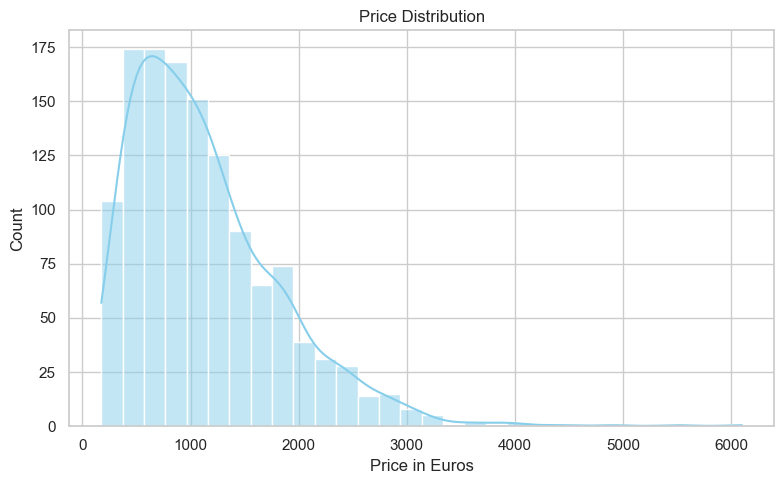

In [39]:
try:
    df = pd.read_csv(r'D:\DS\Unified Mentor\Datasets for Projects UM\laptop_prices.csv')
    print("Data loaded successfully!")
    
    # Initial Data Inspection
    print("\n\033[1mDataset Overview\033[0m")
    print(f"• Training Data: {df.shape[0]} rows, {df.shape[1]} columns")
    
   # Missing Value Analysis
    print("\n\033[1mMissing Values Analysis\033[0m")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

    if missing_values.empty:
        print("• No missing values in the dataset.")
    else:
        print("Columns with missing values:")
    for col, missing in missing_values.items():
        print(f"• {col}: {missing} missing value(s)")

            
    # Identify categorical and numerical features
    print("\n\033[1mFeature Types\033[0m")
    categorical_cols = [feature for feature in df.columns if df[feature].dtype == 'object']
    numerical_cols   = [feature for feature in df.columns if df[feature].dtype != 'object']
    print(f"• Categorical Features: {len(categorical_cols)}")
    print(f"• Numerical Features: {len(numerical_cols)}")

    print("\n\033[1mTarget Variable Summary\033[0m")
    print(df['Price_euros'].describe())
    
    # Visualize target distribution
    sns.set(style="whitegrid")
    # Plot 1: Price distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Price_euros'], kde=True, bins=30, color='skyblue')
    plt.title('Price Distribution')
    plt.xlabel('Price in Euros')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    
except FileNotFoundError:
    print("Error: Dataset files not found. Please ensure train.csv and test.csv are in the working directory.")
except Exception as e:
    print(f"An error occurred: {str(e)}")

In [40]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [41]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [42]:
df.shape

(1275, 23)

## Data Cleaning

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [44]:
df.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [45]:
df.duplicated().sum()

0

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

## Exploratory Data Analysis and Feature Engineering

In [47]:
# Resolution column
df["Resolution"] = df["ScreenW"].astype(str) + "x" + df["ScreenH"].astype(str)

# Convert binary text columns to integers
df["Touchscreen"] = df["Touchscreen"].apply(lambda x: 1 if x == "Yes" else 0)
df["IPSpanel"] = df["IPSpanel"].apply(lambda x: 1 if x == "Yes" else 0)
df["RetinaDisplay"] = df["RetinaDisplay"].apply(lambda x: 1 if x == "Yes" else 0)
 

In [48]:
# Check categorical columns and numerical columns
cat = [col for col in df.select_dtypes(include='object').columns]
num = [col for col in df.columns if col not in cat]
print("Categorical columns: ",cat)
print( "Numerical columns: ",num)

Categorical columns:  ['Company', 'Product', 'TypeName', 'OS', 'Screen', 'CPU_company', 'CPU_model', 'PrimaryStorageType', 'SecondaryStorageType', 'GPU_company', 'GPU_model', 'Resolution']
Numerical columns:  ['Inches', 'Ram', 'Weight', 'Price_euros', 'ScreenW', 'ScreenH', 'Touchscreen', 'IPSpanel', 'RetinaDisplay', 'CPU_freq', 'PrimaryStorage', 'SecondaryStorage']


In [49]:
cat_features = len(cat)
num_features = len(num)
print("Count of Categorical features:", cat_features)
print("Count of Numerical features:", num_features)

Count of Categorical features: 12
Count of Numerical features: 12


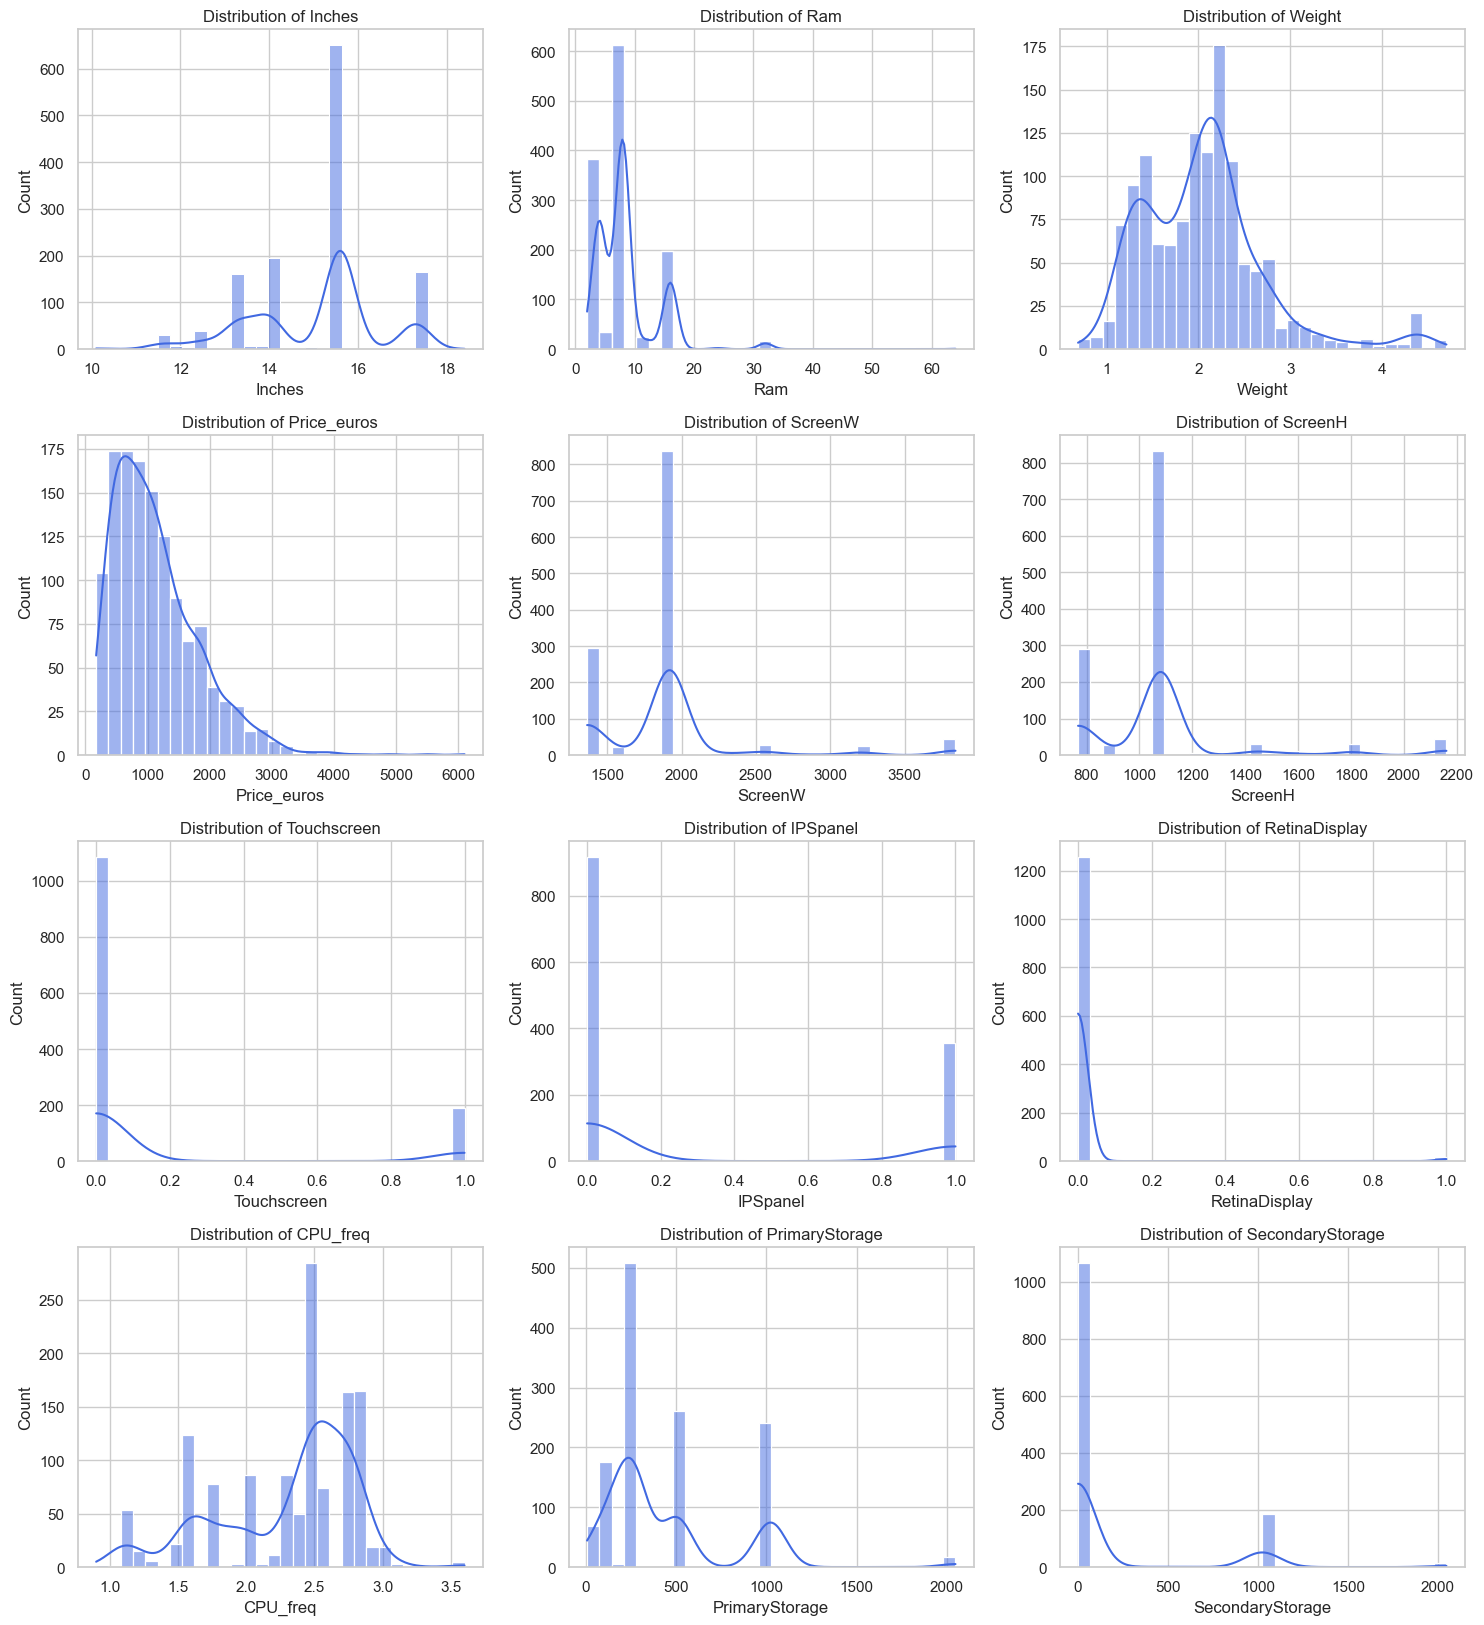

In [50]:
# Plot histograms for numerical columns
plt.figure(figsize=(15, 20))
for i, col in enumerate(num):
    plt.subplot(5, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='royalblue')
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

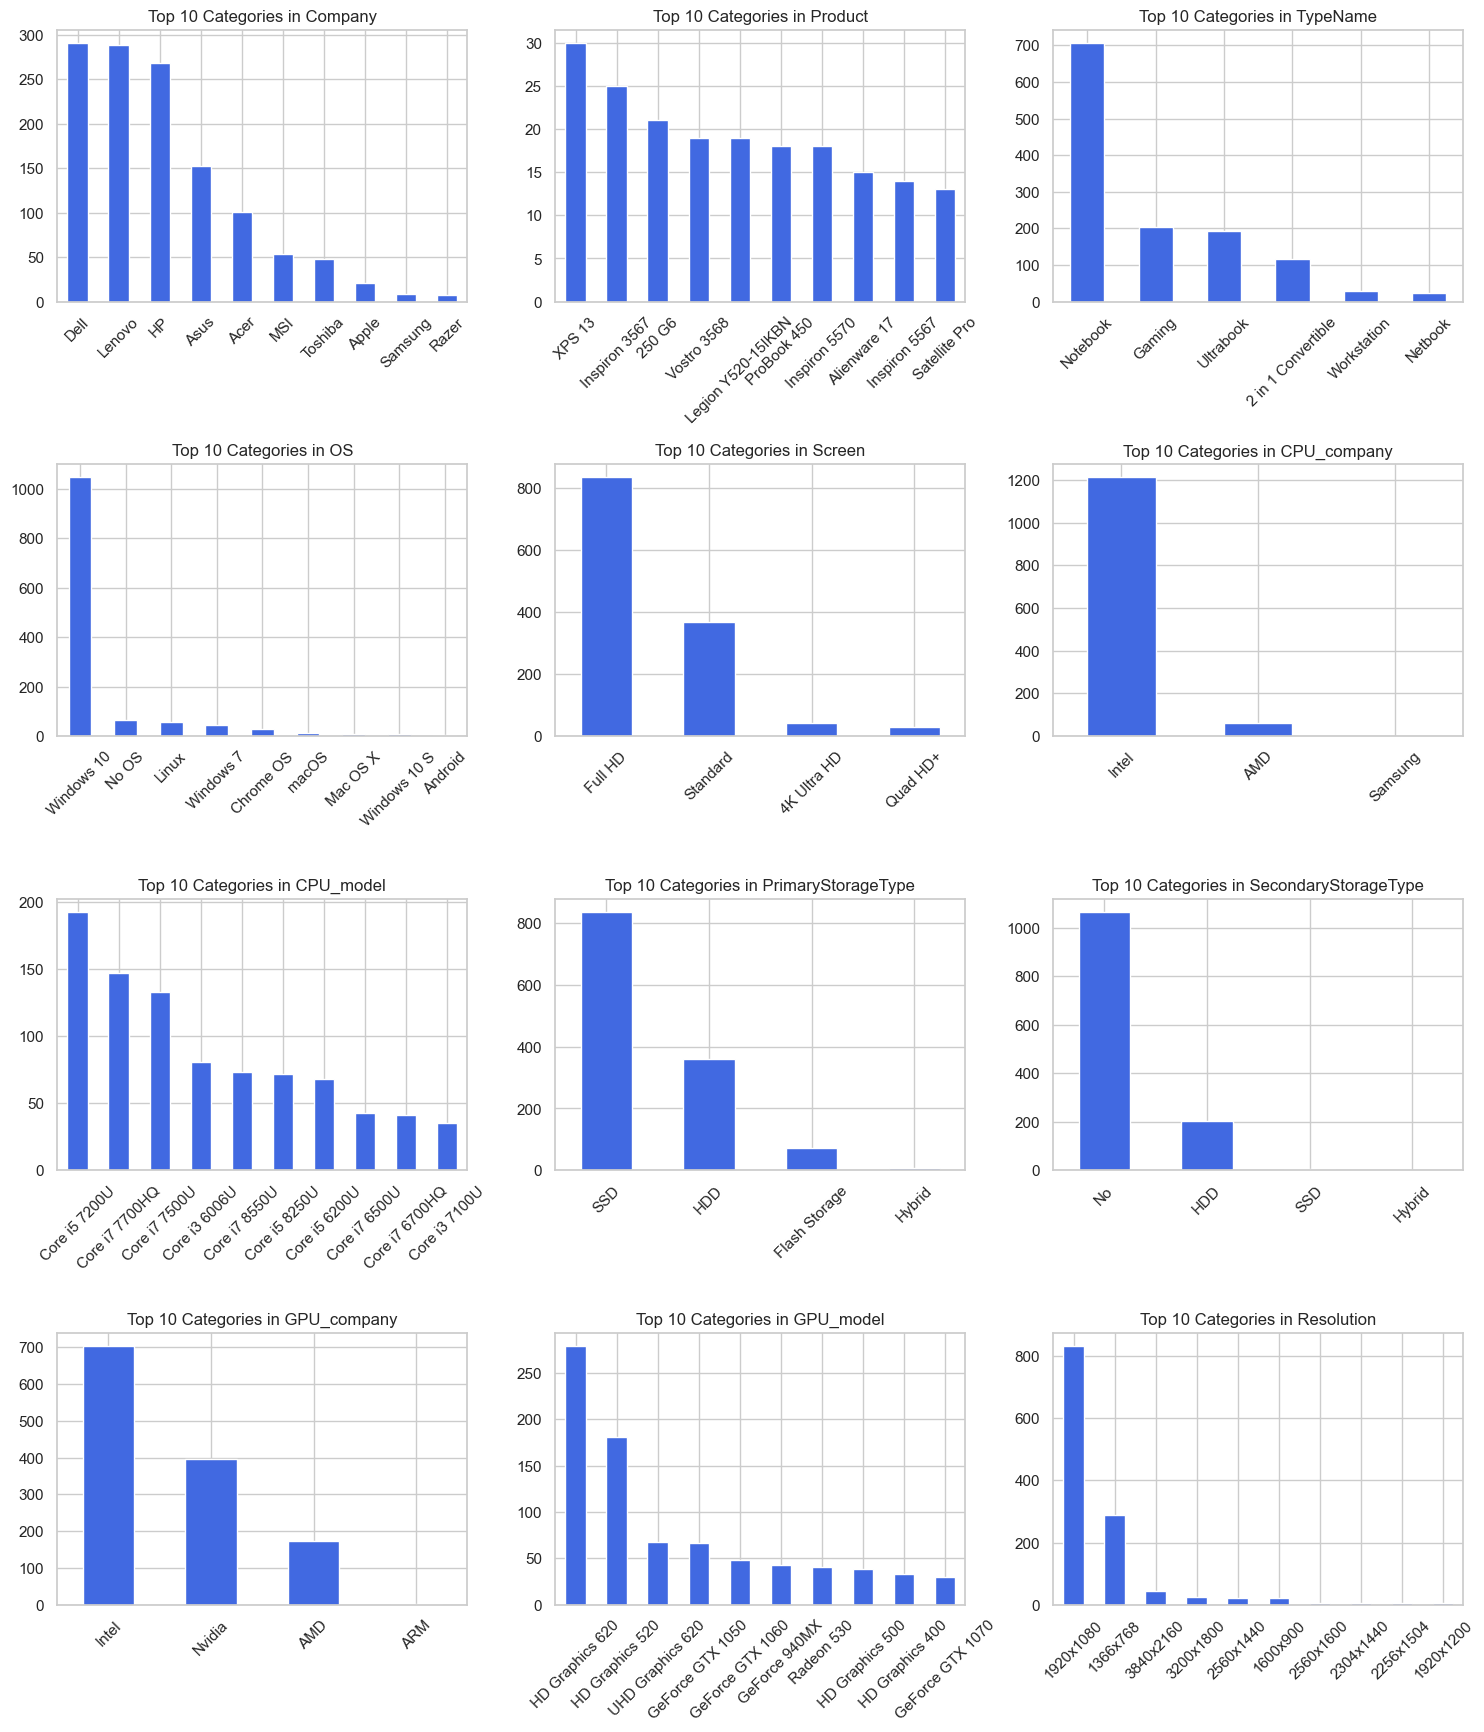

In [51]:
# Plot bar charts for categorical columns

plt.figure(figsize=(15, 25))
for i, col in enumerate(cat):
    plt.subplot(6, 3, i+1)
    df[col].value_counts().head(10).plot(kind='bar',color='royalblue')  # Show top 10 categories
    plt.title(f'Top 10 Categories in {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

<Figure size 1200x6000 with 0 Axes>

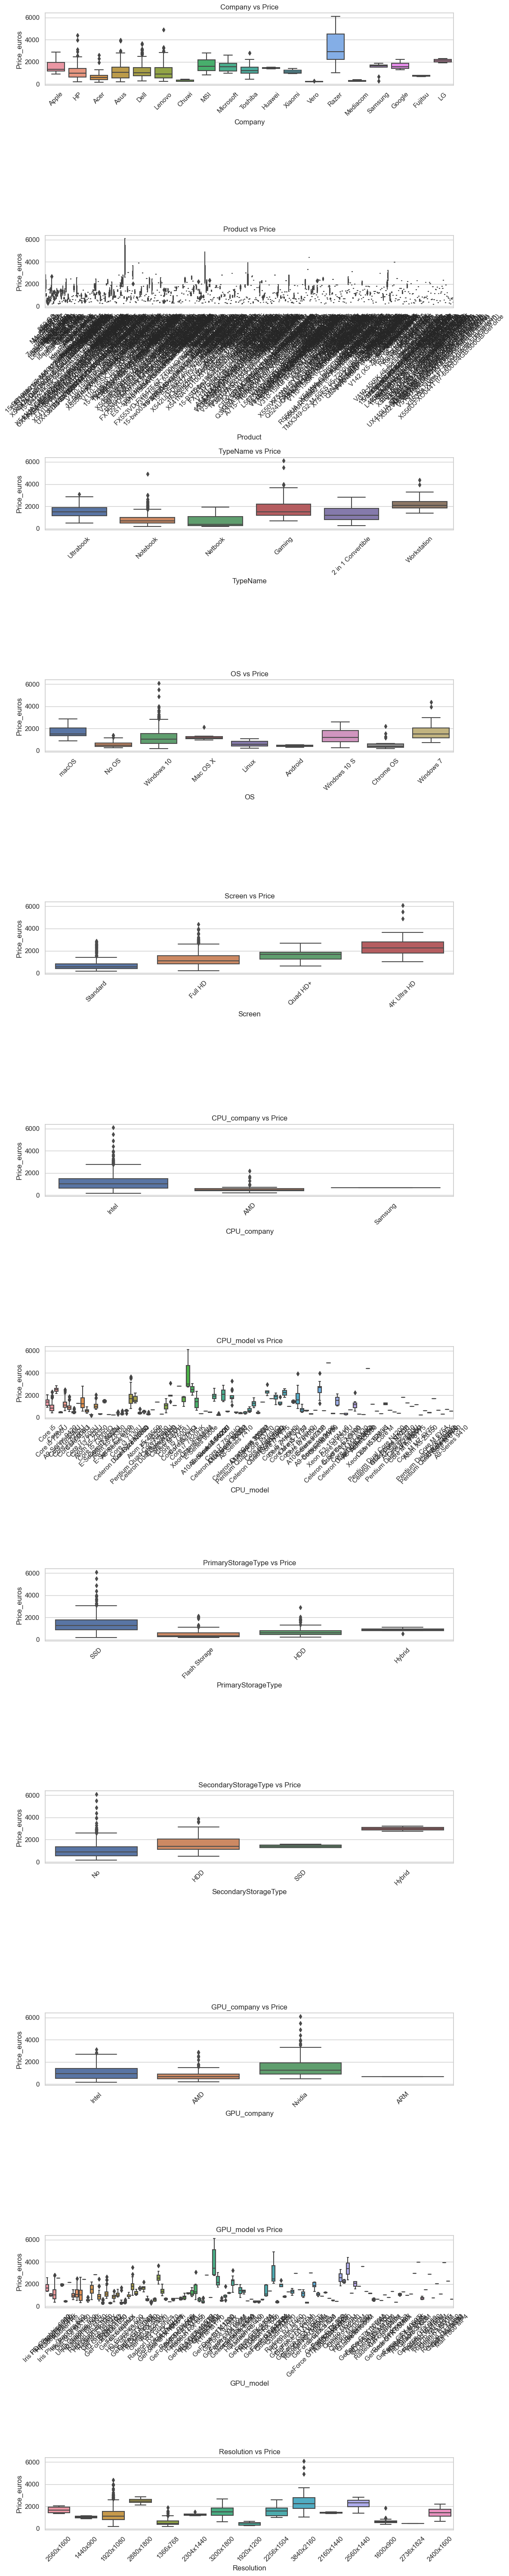

In [52]:
# Categorical features distribution
plt.figure(figsize=(12, 5 * cat_features))  # Dynamic figure height based on number of features
fig, axes = plt.subplots(cat_features, 1, figsize=(12, 5 * cat_features))

# If only one categorical feature, axes won't be an array
if cat_features == 1:plt.figure(figsize=(15, 20))
for i, col in enumerate(cat, 1):
    plt.subplot(len(cat), 1, i)
    sns.boxplot(x=col, y='Price_euros', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()

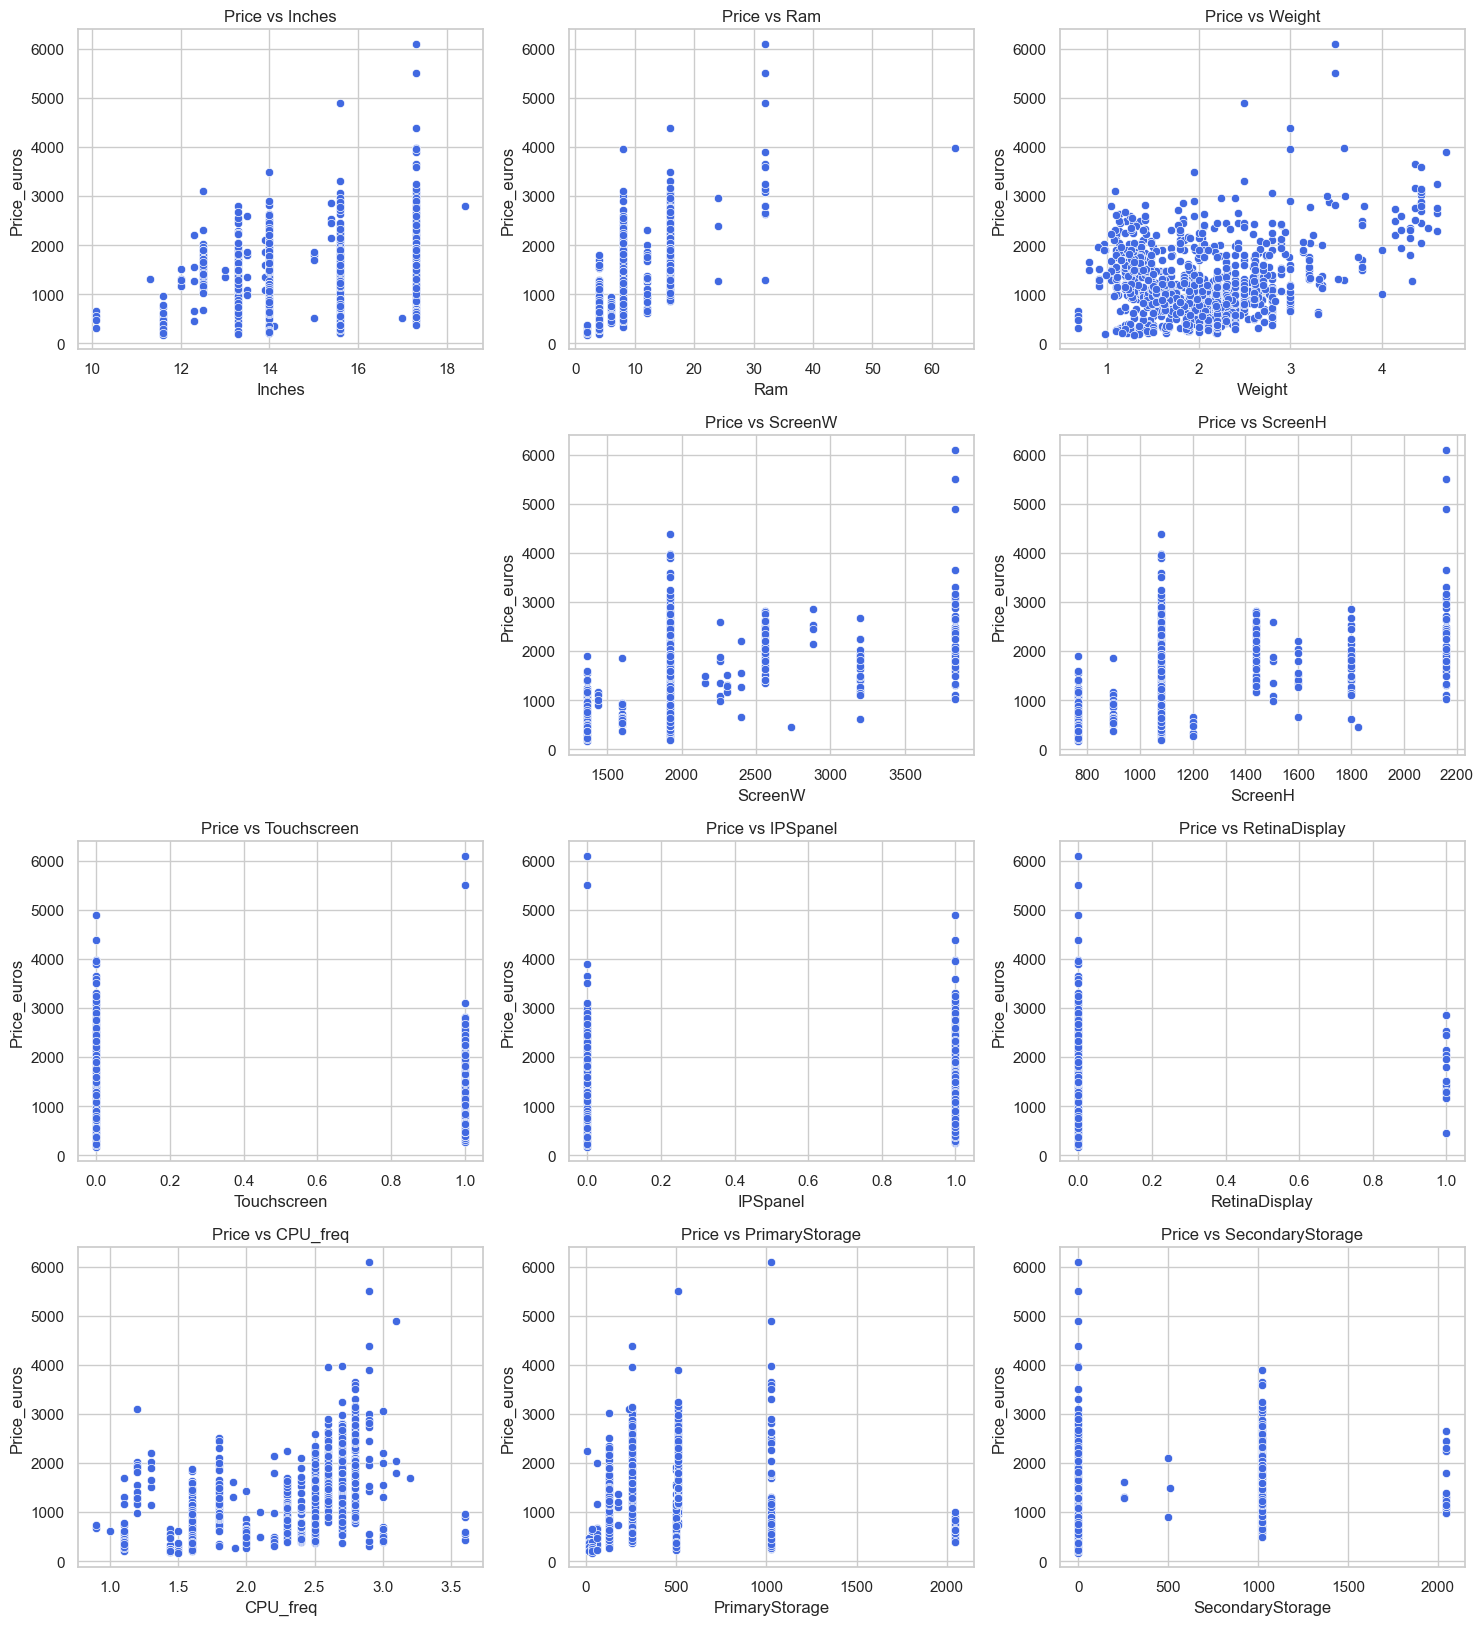

In [53]:
# Scatter plots of price vs numerical features
plt.figure(figsize=(15, 20))
for i, col in enumerate(num):
    if col != 'Price_euros':  # Don't plot price against itself
        plt.subplot(5, 3, i+1)
        sns.scatterplot(x=df[col], y=df['Price_euros'], color='royalblue')
        plt.title(f'Price vs {col}')
        plt.tight_layout()
plt.show()

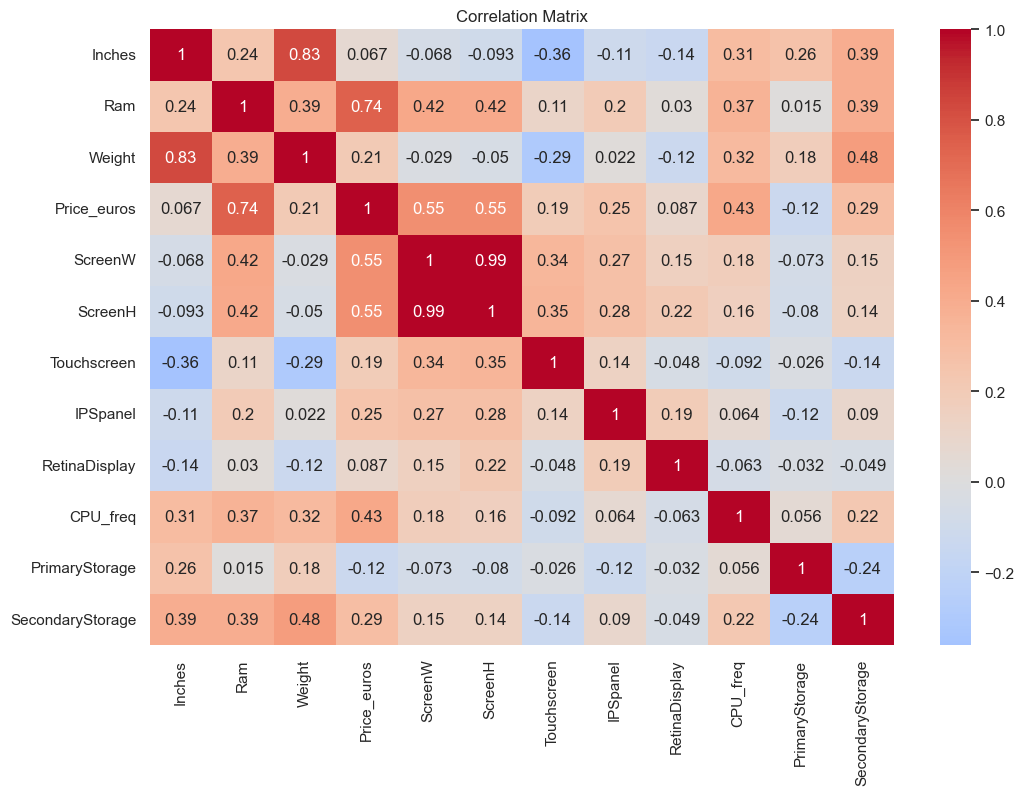

In [54]:
# Correlation matrix
corr_matrix = df[num].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [55]:
# Top correlations with price
price_corr = corr_matrix['Price_euros'].sort_values(ascending=False)
print("\nTop correlations with Price_euros:")
print(price_corr)


Top correlations with Price_euros:
Price_euros         1.000000
Ram                 0.740287
ScreenW             0.552491
ScreenH             0.548529
CPU_freq            0.428847
SecondaryStorage    0.291207
IPSpanel            0.250737
Weight              0.211883
Touchscreen         0.188886
RetinaDisplay       0.086775
Inches              0.066608
PrimaryStorage     -0.124775
Name: Price_euros, dtype: float64


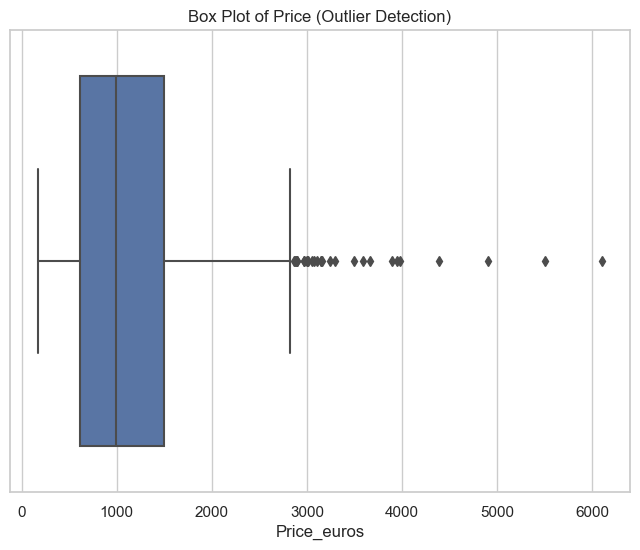


Top 10 most expensive laptops:
     Company            Product  Price_euros
196    Razer          Blade Pro       6099.0
830    Razer          Blade Pro       5499.0
610   Lenovo       Thinkpad P51       4899.0
749       HP           Zbook 17       4389.0
1066    Asus         ROG G701VO       3975.0
1136      HP           ZBook 17       3949.4
238     Asus  ROG G703VI-E5062T       3890.0
723     Dell       Alienware 17       3659.4
780     Dell       Alienware 17       3588.8
1231   Razer          Blade Pro       3499.0


In [56]:
# Box plot for price to detect outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Price_euros'])
plt.title('Box Plot of Price (Outlier Detection)')
plt.show()

# Identify the most expensive laptops
print("\nTop 10 most expensive laptops:")
print(df.nlargest(10, 'Price_euros')[['Company', 'Product', 'Price_euros']])

In [57]:
num_col = [col for col in num if col != 'Price_euros']


In [58]:
# Define features and target
X = df.drop("Price_euros", axis = 1)
y = np.log(df["Price_euros"])

# Build preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_col),
    ("cat", OneHotEncoder(drop="first",handle_unknown='ignore'), cat)
])

## Splitting the dataset into training and testing dataset

In [59]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [60]:
X_train.shape

(1020, 23)

In [61]:
y_train.shape

(1020,)

In [62]:
X_test.shape

(255, 23)

In [63]:
y_test.shape

(255,)

In [64]:

# Pipelines
lr_pipeline = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
ridge_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Ridge())])
lasso_pipeline = Pipeline([("preprocessor", preprocessor), ("model", Lasso())])

# Fit baseline model
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)


## Evaluation of the predictive model

In [65]:
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} MSE: {mse:.2f}, R²: {r2:.2f}")

### Linear Regression

In [66]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression MSE: 0.05, R²: 0.85


### Ridge and Lasso Regression

In [67]:
# GridSearch for Ridge
ridge_params = {"model__alpha": [0.1, 1, 10, 50, 100]}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5)
ridge_grid.fit(X_train, y_train)
evaluate_model(y_test, ridge_grid.predict(X_test), "Ridge")

# GridSearch for Lasso
lasso_params = {"model__alpha": [0.1, 1, 10, 50, 100]}
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5)
lasso_grid.fit(X_train, y_train)
evaluate_model(y_test, lasso_grid.predict(X_test), "Lasso")

Ridge MSE: 0.03, R²: 0.91
Lasso MSE: 0.15, R²: 0.57


In [68]:
# Define the base pipeline structure
def make_model_pipeline(model):
    return Pipeline([
        ('columntransformer', preprocessor),
        ('model', model)
    ])


### Random Forest

In [69]:
# Random Forest
rf_params = {
    'model__n_estimators': [100],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}
rf_pipeline = make_model_pipeline(RandomForestRegressor(random_state=42))
rf_grid = GridSearchCV(rf_pipeline, rf_params, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)
evaluate_model(y_test, rf_grid.predict(X_test), "Random Forest")


Random Forest MSE: 0.04, R²: 0.89


### Support Vector Machine

In [70]:
# Support Vector Machine
svm_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}
svm_pipeline = make_model_pipeline(SVR())
svm_grid = GridSearchCV(svm_pipeline, svm_params, cv=5, n_jobs=-1)
svm_grid.fit(X_train, y_train)
evaluate_model(y_test, svm_grid.predict(X_test), "SVM")



SVM MSE: 0.03, R²: 0.90


### K - Nearest Neighbors (KNN)

In [71]:
# K-Nearest Neighbors
knn_params = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}
knn_pipeline = make_model_pipeline(KNeighborsRegressor())
knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=5, n_jobs=-1)
knn_grid.fit(X_train, y_train)
evaluate_model(y_test, knn_grid.predict(X_test), "KNN")



KNN MSE: 0.06, R²: 0.81


### XGBoost

In [72]:
# XGBoost
xgb_params = {
    'model__n_estimators': [100],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1, 0.2]
}
xgb_pipeline = make_model_pipeline(XGBRegressor(random_state=42))
xgb_grid = GridSearchCV(xgb_pipeline, xgb_params, cv=5, n_jobs=-1)
xgb_grid.fit(X_train, y_train)
evaluate_model(y_test, xgb_grid.predict(X_test), "XGBoost")



XGBoost MSE: 0.03, R²: 0.90


### Decision Tree

In [73]:
# Decision Tree
dt_params = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}
dt_pipeline = make_model_pipeline(DecisionTreeRegressor(random_state=42))
dt_grid = GridSearchCV(dt_pipeline, dt_params, cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)
evaluate_model(y_test, dt_grid.predict(X_test), "Decision Tree")

Decision Tree MSE: 0.06, R²: 0.82


### Extra Tree Regressor

In [74]:
# Extra Trees Regressor
et_params = {
    'model__n_estimators': [100],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5],
    'model__bootstrap': [False]
}

et_pipeline = make_model_pipeline(ExtraTreesRegressor(random_state=42))
et_grid = GridSearchCV(et_pipeline, et_params, cv=3, n_jobs=-1)
et_grid.fit(X_train, y_train)
evaluate_model(y_test, et_grid.predict(X_test), "Extra Trees")

Extra Trees MSE: 0.04, R²: 0.87


### Stacking

In [75]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

# Define base estimators
estimators = [
    ('ridge', RidgeCV()),
    ('lasso', Lasso(random_state=42)),
    ('rf', RandomForestRegressor(random_state=42, n_estimators=50))
]

# Stacking Regressor
stacking_params = {
    'model__final_estimator': [RidgeCV(), Lasso(random_state=42)],
    'model__passthrough': [True, False]
}

stacking_pipeline = make_model_pipeline(
    StackingRegressor(
        estimators=estimators,
        cv=5,
        n_jobs=-1
    )
)
stacking_grid = GridSearchCV(stacking_pipeline, stacking_params, cv=5)
stacking_grid.fit(X_train, y_train)
evaluate_model(y_test, stacking_grid.predict(X_test), "Stacking")

Stacking MSE: 0.03, R²: 0.92


### Best Model for Laptop Price Prediction

Best model to predict the laptop prices is Ridge Regressor with GridSearchCV- 
Ridge Regressor MSE: 0.03, R²: 0.91

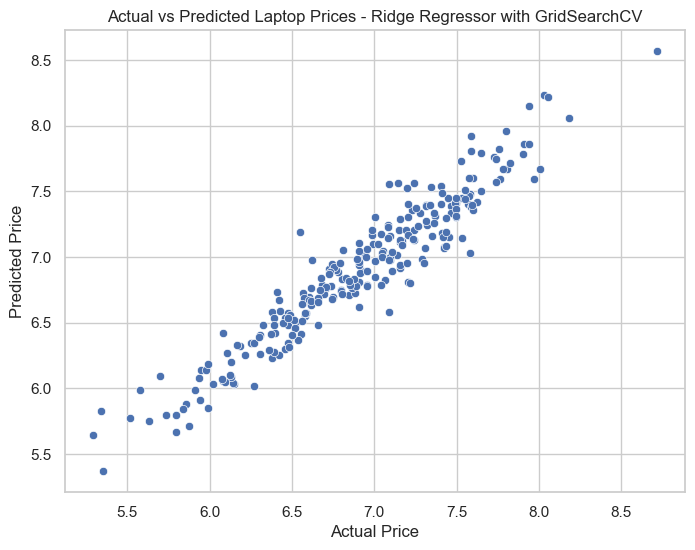

In [78]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=ridge_grid.predict(X_test))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices - Ridge Regressor with GridSearchCV")
plt.show()